
# Past Dog Infos Data Quality Audit

This notebook treats `all_dog_infos` like a production ML dataset audit.
We inspect schema, duplicates, missingness, outliers, and leakage risk, then build a cleaned dataframe that is safer to use in downstream training pipelines.


In [2]:

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore")



## Load Raw Data

We read with `low_memory=False` so pandas does not infer inconsistent dtypes chunk-by-chunk.


In [3]:

DATA_PATH = Path("../data/raw/all_dog_infos.csv")
OUTPUT_PATH = Path("../data/interim/all_dog_infos_cleaned.parquet")
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

all_dog_infos = pd.read_csv(DATA_PATH, low_memory=False)
raw_df = all_dog_infos.copy()

print(f"Loaded {DATA_PATH}")
print(f"Shape: {all_dog_infos.shape[0]:,} rows x {all_dog_infos.shape[1]:,} columns")
print(f"Approx memory usage: {all_dog_infos.memory_usage(deep=True).sum() / 1024**2:,.1f} MB")


Loaded ../data/raw/all_dog_infos.csv
Shape: 3,400,585 rows x 22 columns
Approx memory usage: 2,099.6 MB



## Helper Functions

These utilities keep the audit reproducible and make the cleaning logic explicit.


In [4]:

def clean_sp_token(value):
    if pd.isna(value):
        return np.nan
    token = str(value).strip().upper()
    token = token.replace("F", "")
    token = token.replace("J", "")
    token = token.replace("CF", "")
    token = token.replace("C", "")
    token = token.strip()
    if token in {"", "NAN", "NONE"}:
        return np.nan
    if token in {"EVS", "EVENS", "EVEN"}:
        return 1.0
    if "/" in token:
        left, right = token.split("/", 1)
        try:
            return float(left) / float(right)
        except (TypeError, ValueError, ZeroDivisionError):
            return np.nan
    try:
        return float(token)
    except ValueError:
        return np.nan


def convert_distance_token(value):
    mapping = {
        "SH": 0.10,
        "S/H": 0.10,
        "HD": 0.20,
        "DH": 0.20,
        "NK": 0.30,
        "SNK": 0.25,
        "NSE": 0.05,
        "NOSE": 0.05,
    }
    if pd.isna(value):
        return np.nan
    token = str(value).strip().upper()
    if token in {"", "NAN", "NONE", "DIS", "DNF", "VOID"}:
        return np.nan
    if token in mapping:
        return mapping[token]

    total = 0.0
    for part in token.split():
        if part in mapping:
            total += mapping[part]
            continue
        if "/" in part:
            try:
                numerator, denominator = part.split("/", 1)
                total += float(numerator) / float(denominator)
                continue
            except (TypeError, ValueError, ZeroDivisionError):
                return np.nan
        try:
            total += float(part)
        except ValueError:
            return np.nan
    return total


def summarize_columns(df):
    summary = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "missing": df.isna().sum(),
        "missing_pct": df.isna().mean().mul(100),
        "n_unique": df.nunique(dropna=True),
        "example": [df[c].dropna().iloc[0] if df[c].notna().any() else np.nan for c in df.columns],
    })
    return summary.sort_values(["missing_pct", "n_unique"], ascending=[False, False])


def iqr_outlier_summary(df, numeric_cols, whisker=1.5):
    rows = []
    for col in numeric_cols:
        s = pd.to_numeric(df[col], errors="coerce")
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        low = q1 - whisker * iqr
        high = q3 + whisker * iqr
        mask = (s < low) | (s > high)
        rows.append({
            "column": col,
            "non_null": int(s.notna().sum()),
            "q1": q1,
            "median": s.median(),
            "q3": q3,
            "iqr": iqr,
            "lower_bound": low,
            "upper_bound": high,
            "min": s.min(),
            "max": s.max(),
            "outlier_count": int(mask.sum()),
            "outlier_pct": mask.mean() * 100,
            "zero_count": int((s == 0).sum()),
            "negative_count": int((s < 0).sum()),
        })
    return pd.DataFrame(rows).sort_values("outlier_pct", ascending=False)


def rare_category_summary(df, categorical_cols, top_n=15):
    frames = []
    for col in categorical_cols:
        value_counts = df[col].astype(str).value_counts(dropna=False)
        share = value_counts / len(df) * 100
        top = pd.DataFrame({
            "column": col,
            "value": value_counts.index.astype(str),
            "count": value_counts.values,
            "pct": share.values,
        }).head(top_n)
        frames.append(top)
    return pd.concat(frames, ignore_index=True)


In [5]:

def grouped_missingness_summary(df, target_col, group_cols, min_rows=1):
    summary = (
        df.groupby(group_cols, dropna=False)
        .agg(
            rows=(target_col, "size"),
            non_missing=(target_col, lambda s: s.notna().sum()),
            missing=(target_col, lambda s: s.isna().sum()),
        )
        .reset_index()
    )
    summary["missing_pct"] = summary["missing"] / summary["rows"] * 100
    summary["non_missing_pct"] = summary["non_missing"] / summary["rows"] * 100
    summary = summary.loc[summary["rows"] >= min_rows]
    return summary.sort_values(["missing_pct", "rows"], ascending=[False, False]).reset_index(drop=True)



## Initial Audit


In [6]:

column_summary = summarize_columns(all_dog_infos)
column_summary


,dtype,non_null,missing,missing_pct,n_unique,example
resultSectionalTime,float64,2775321,625264,18.3870,3136,4.4600
resultBtnDistance,str,2804473,596112,17.5297,211,2
raceGoing,float64,2838849,561736,16.5188,74,0.0000
resultAdjustedTime,float64,3341081,59504,1.7498,4317,28.7300
resultRunTime,float64,3341081,59504,1.7498,4302,28.7300
raceWinTime,float64,3382824,17761,0.5223,3406,28.2400
winnerOr2ndId,float64,3383047,17538,0.5157,76988,"535,490.0000"
winnerOr2ndName,str,3383047,17538,0.5157,76894,Shelbys Memory
SP,str,3383481,17104,0.5030,150,5/4
resultDogWeight,float64,3388946,11639,0.3423,263,34.1000


In [7]:

duplicate_audit = pd.DataFrame([
    {"grain": "full_row", "duplicate_rows": int(all_dog_infos.duplicated().sum())},
    {"grain": "dogId + meetingId", "duplicate_rows": int(all_dog_infos.duplicated(subset=["dogId", "meetingId"]).sum())},
    {"grain": "dogId + raceId", "duplicate_rows": int(all_dog_infos.duplicated(subset=["dogId", "raceId"]).sum())},
    {"grain": "meetingId + raceId + dogId", "duplicate_rows": int(all_dog_infos.duplicated(subset=["meetingId", "raceId", "dogId"]).sum())},
    {"grain": "raceId + trapNumber", "duplicate_rows": int(all_dog_infos.duplicated(subset=["raceId", "trapNumber"]).sum())},
])
duplicate_audit


,grain,duplicate_rows
0,full_row,0
1,dogId + meetingId,9
2,dogId + raceId,0
3,meetingId + raceId + dogId,0
4,raceId + trapNumber,0


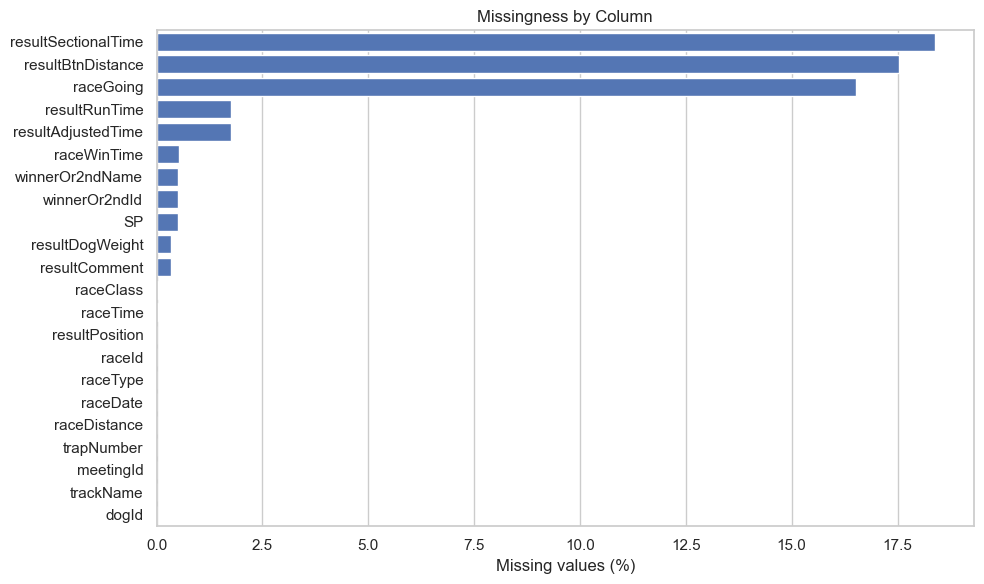

,missing_pct
resultSectionalTime,18.3870
resultBtnDistance,17.5297
raceGoing,16.5188
resultRunTime,1.7498
resultAdjustedTime,1.7498
raceWinTime,0.5223
winnerOr2ndName,0.5157
winnerOr2ndId,0.5157
SP,0.5030
resultDogWeight,0.3423


In [8]:

missingness = (
    all_dog_infos.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_pct")
    .to_frame()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=missingness.reset_index(), x="missing_pct", y="index", color="#4472c4")
plt.title("Missingness by Column")
plt.xlabel("Missing values (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

missingness



## Missingness by Track Context

The next tables check whether `resultSectionalTime` and `raceGoing` are missing uniformly, or whether the missingness is concentrated in specific tracks, track-distance combinations, or track-distance-class combinations.


In [9]:

result_sectional_time_missing_by_track = grouped_missingness_summary(
    all_dog_infos,
    target_col="resultSectionalTime",
    group_cols=["trackName"],
)

result_sectional_time_missing_by_track_distance = grouped_missingness_summary(
    all_dog_infos,
    target_col="resultSectionalTime",
    group_cols=["trackName", "raceDistance"],
)

result_sectional_time_missing_by_track_distance_class = grouped_missingness_summary(
    all_dog_infos,
    target_col="resultSectionalTime",
    group_cols=["trackName", "raceDistance", "raceClass"],
)

race_going_missing_by_track = grouped_missingness_summary(
    all_dog_infos,
    target_col="raceGoing",
    group_cols=["trackName"],
)

race_going_missing_by_track_distance = grouped_missingness_summary(
    all_dog_infos,
    target_col="raceGoing",
    group_cols=["trackName", "raceDistance"],
)

race_going_missing_by_track_distance_class = grouped_missingness_summary(
    all_dog_infos,
    target_col="raceGoing",
    group_cols=["trackName", "raceDistance", "raceClass"],
)

overall_missing_focus = missingness.loc[["resultSectionalTime", "raceGoing"]].rename_axis("column")
overall_missing_focus


,missing_pct
column,
resultSectionalTime,18.3870
raceGoing,16.5188


In [10]:
display(result_sectional_time_missing_by_track_distance.head(100))

,trackName,raceDistance,rows,non_missing,missing,missing_pct,non_missing_pct
0,Harlow,238.0000,62243,0,62243,100.0000,0.0000
1,Central Park,265.0000,39169,0,39169,100.0000,0.0000
2,Kinsley,268.0000,35766,0,35766,100.0000,0.0000
3,Sunderland,261.0000,21067,0,21067,100.0000,0.0000
4,Newcastle,290.0000,9148,0,9148,100.0000,0.0000
5,Towcester,260.0000,7542,0,7542,100.0000,0.0000
6,Henlow,277.0000,7386,0,7386,100.0000,0.0000
7,Oxford,253.0000,4776,0,4776,100.0000,0.0000
8,Sittingbourne,265.0000,2397,0,2397,100.0000,0.0000
9,Belle Vue,260.0000,1975,0,1975,100.0000,0.0000


In [16]:
display(result_sectional_time_missing_by_track_distance_class.head(350))

,trackName,raceDistance,raceClass,rows,non_missing,missing,missing_pct,non_missing_pct
0,Newcastle,480.0000,HP,32945,0,32945,100.0000,0.0000
1,Harlow,238.0000,D4,28032,0,28032,100.0000,0.0000
2,Shawfield,480.0000,HP,26078,0,26078,100.0000,0.0000
3,Sunderland,450.0000,HP,16637,0,16637,100.0000,0.0000
4,Harlow,238.0000,D3,16205,0,16205,100.0000,0.0000
...,...,...,...,...,...,...,...,...
345,Swindon,262.0000,D3,2105,3,2102,99.8575,0.1425
346,Swindon,262.0000,D2,1365,2,1363,99.8535,0.1465
347,Perry Barr,275.0000,D2,4093,7,4086,99.8290,0.1710
348,Hove,285.0000,OR,3308,6,3302,99.8186,0.1814


In [16]:

display(result_sectional_time_missing_by_track)
display(result_sectional_time_missing_by_track_distance.head(30))
display(result_sectional_time_missing_by_track_distance_class.head(30))

display(race_going_missing_by_track)
display(race_going_missing_by_track_distance.head(30))
display(race_going_missing_by_track_distance_class.head(30))


,trackName,rows,non_missing,missing,missing_pct,non_missing_pct
0,Shawfield,28786,1858,26928,93.5455,6.4545
1,Valley,11863,5863,6000,50.5774,49.4226
2,The Valley,59,30,29,49.1525,50.8475
3,Central Park,133423,75178,58245,43.6544,56.3456
4,Harlow,147884,85289,62595,42.3271,57.6729
5,Kinsley,154950,102933,52017,33.5702,66.4298
6,Towcester,113710,77151,36559,32.1511,67.8489
7,Sheffield,208948,150847,58101,27.8064,72.1936
8,Newcastle,196143,146160,49983,25.4829,74.5171
9,Perry Barr,162845,123284,39561,24.2937,75.7063


,trackName,raceDistance,rows,non_missing,missing,missing_pct,non_missing_pct
0,Harlow,238.0000,62243,0,62243,100.0000,0.0000
1,Central Park,265.0000,39169,0,39169,100.0000,0.0000
2,Kinsley,268.0000,35766,0,35766,100.0000,0.0000
3,Sunderland,261.0000,21067,0,21067,100.0000,0.0000
4,Newcastle,290.0000,9148,0,9148,100.0000,0.0000
5,Towcester,260.0000,7542,0,7542,100.0000,0.0000
6,Henlow,277.0000,7386,0,7386,100.0000,0.0000
7,Oxford,253.0000,4776,0,4776,100.0000,0.0000
8,Sittingbourne,265.0000,2397,0,2397,100.0000,0.0000
9,Belle Vue,260.0000,1975,0,1975,100.0000,0.0000


,trackName,raceDistance,raceClass,rows,non_missing,missing,missing_pct,non_missing_pct
0,Newcastle,480.0000,HP,32945,0,32945,100.0000,0.0000
1,Harlow,238.0000,D4,28032,0,28032,100.0000,0.0000
2,Shawfield,480.0000,HP,26078,0,26078,100.0000,0.0000
3,Sunderland,450.0000,HP,16637,0,16637,100.0000,0.0000
4,Harlow,238.0000,D3,16205,0,16205,100.0000,0.0000
5,Kinsley,268.0000,D3,12949,0,12949,100.0000,0.0000
6,Kinsley,462.0000,HP,12603,0,12603,100.0000,0.0000
7,Central Park,265.0000,D2,11893,0,11893,100.0000,0.0000
8,Sheffield,500.0000,HP,11628,0,11628,100.0000,0.0000
9,Central Park,265.0000,D3,9500,0,9500,100.0000,0.0000


,trackName,rows,non_missing,missing,missing_pct,non_missing_pct
0,Coventry,1112,180,932,83.8129,16.1871
1,Henlow,125180,88515,36665,29.2898,70.7102
2,Sittingbourne,26570,19026,7544,28.3929,71.6071
3,Wimbledon,20284,15405,4879,24.0534,75.9466
4,Poole,66908,51386,15522,23.1990,76.8010
5,Belle Vue,87401,67365,20036,22.9242,77.0758
6,Mildenhall,13026,10119,2907,22.3169,77.6831
7,Hall Green,49248,39393,9855,20.0110,79.9890
8,Crayford,219599,176870,42729,19.4577,80.5423
9,Perry Barr,162845,131445,31400,19.2821,80.7179


,trackName,raceDistance,rows,non_missing,missing,missing_pct,non_missing_pct
0,Crayford,60.0000,31,0,31,100.0000,0.0000
1,Swindon,514.0000,17,0,17,100.0000,0.0000
2,Coventry,672.0000,16,0,16,100.0000,0.0000
3,Central Park,0.0000,3,0,3,100.0000,0.0000
4,Pelaw Grange,0.0000,2,0,2,100.0000,0.0000
5,Nottingham,100.0000,1,0,1,100.0000,0.0000
6,Swindon,0.0000,1,0,1,100.0000,0.0000
7,Swindon,229.0000,1,0,1,100.0000,0.0000
8,Sheffield,100.0000,17,1,16,94.1176,5.8824
9,Towcester,0.0000,9,1,8,88.8889,11.1111


,trackName,raceDistance,raceClass,rows,non_missing,missing,missing_pct,non_missing_pct
0,Wimbledon,480.0000,A8,118,0,118,100.0000,0.0000
1,Peterborough,250.0000,A15,35,0,35,100.0000,0.0000
2,Swindon,649.0000,S1,33,0,33,100.0000,0.0000
3,Crayford,60.0000,NaN,31,0,31,100.0000,0.0000
4,Crayford,540.0000,HS2,23,0,23,100.0000,0.0000
5,Henlow,460.0000,P1,21,0,21,100.0000,0.0000
6,Sittingbourne,480.0000,P3,18,0,18,100.0000,0.0000
7,Swindon,514.0000,OR,17,0,17,100.0000,0.0000
8,Coventry,672.0000,OR,16,0,16,100.0000,0.0000
9,Swindon,285.0000,D1,16,0,16,100.0000,0.0000



## Mixed-Type and Categorical Diagnostics

The columns below are the most likely to need parsing before training.


In [7]:

problem_columns = ["SP", "resultBtnDistance", "trapNumber", "raceType", "raceClass", "resultPosition"]
rare_category_summary(all_dog_infos, problem_columns, top_n=20)


,column,value,count,pct
0,SP,4/1,338657,9.9588
1,SP,5/1,300381,8.8332
2,SP,3/1,271543,7.9852
3,SP,6/1,268874,7.9067
4,SP,7/2,264212,7.7696
5,SP,8/1,170406,5.0111
6,SP,9/2,167458,4.9244
7,SP,7/1,159897,4.7020
8,SP,5/2,138682,4.0782
9,SP,10/1,99715,2.9323



## Numeric Outlier Audit

We start with an IQR-based screen, then layer in domain rules for clearly impossible values.


In [8]:

numeric_cols = [
    "resultPosition",
    "resultSectionalTime",
    "resultRunTime",
    "resultDogWeight",
    "winnerOr2ndId",
    "resultAdjustedTime",
    "raceDistance",
    "raceGoing",
    "raceWinTime",
]

outlier_summary = iqr_outlier_summary(all_dog_infos, numeric_cols)
outlier_summary


,column,non_null,q1,median,q3,iqr,lower_bound,upper_bound,min,max,outlier_count,outlier_pct,zero_count,negative_count
8,raceWinTime,3382824,25.9900,28.7100,29.7400,3.7500,20.3650,35.3650,0.2600,69.4200,565752,16.6369,0,0
5,resultAdjustedTime,3341081,26.3200,29.0200,30.0800,3.7600,20.6800,35.7200,0.2600,228.9500,561653,16.5164,0,0
2,resultRunTime,3341081,26.2800,29.0500,30.0900,3.8100,20.5650,35.8050,0.2600,228.9500,557915,16.4064,0,0
6,raceDistance,3400585,415.0000,470.0000,480.0000,65.0000,317.5000,577.5000,0.0000,"1,048.0000",541732,15.9306,36,0
1,resultSectionalTime,2775321,3.8500,4.4700,5.1000,1.2500,1.9750,6.9750,0.0000,95.3100,187022,5.4997,952,0
7,raceGoing,2838849,-10.0000,0.0000,10.0000,20.0000,-40.0000,40.0000,-340.0000,"2,105.0000",127417,3.7469,916680,989358
4,winnerOr2ndId,3383047,"460,096.0000","503,831.0000","548,791.0000","88,695.0000","327,053.5000","681,833.5000",744.0000,"652,166.0000",10723,0.3153,0,0
3,resultDogWeight,3388946,27.2000,29.8000,32.6000,5.4000,19.1000,40.7000,0.0000,"2,855.0000",2822,0.0830,1776,0
0,resultPosition,3400428,2.0000,3.0000,5.0000,3.0000,-2.5000,9.5000,0.0000,8.0000,0,0.0000,17475,0


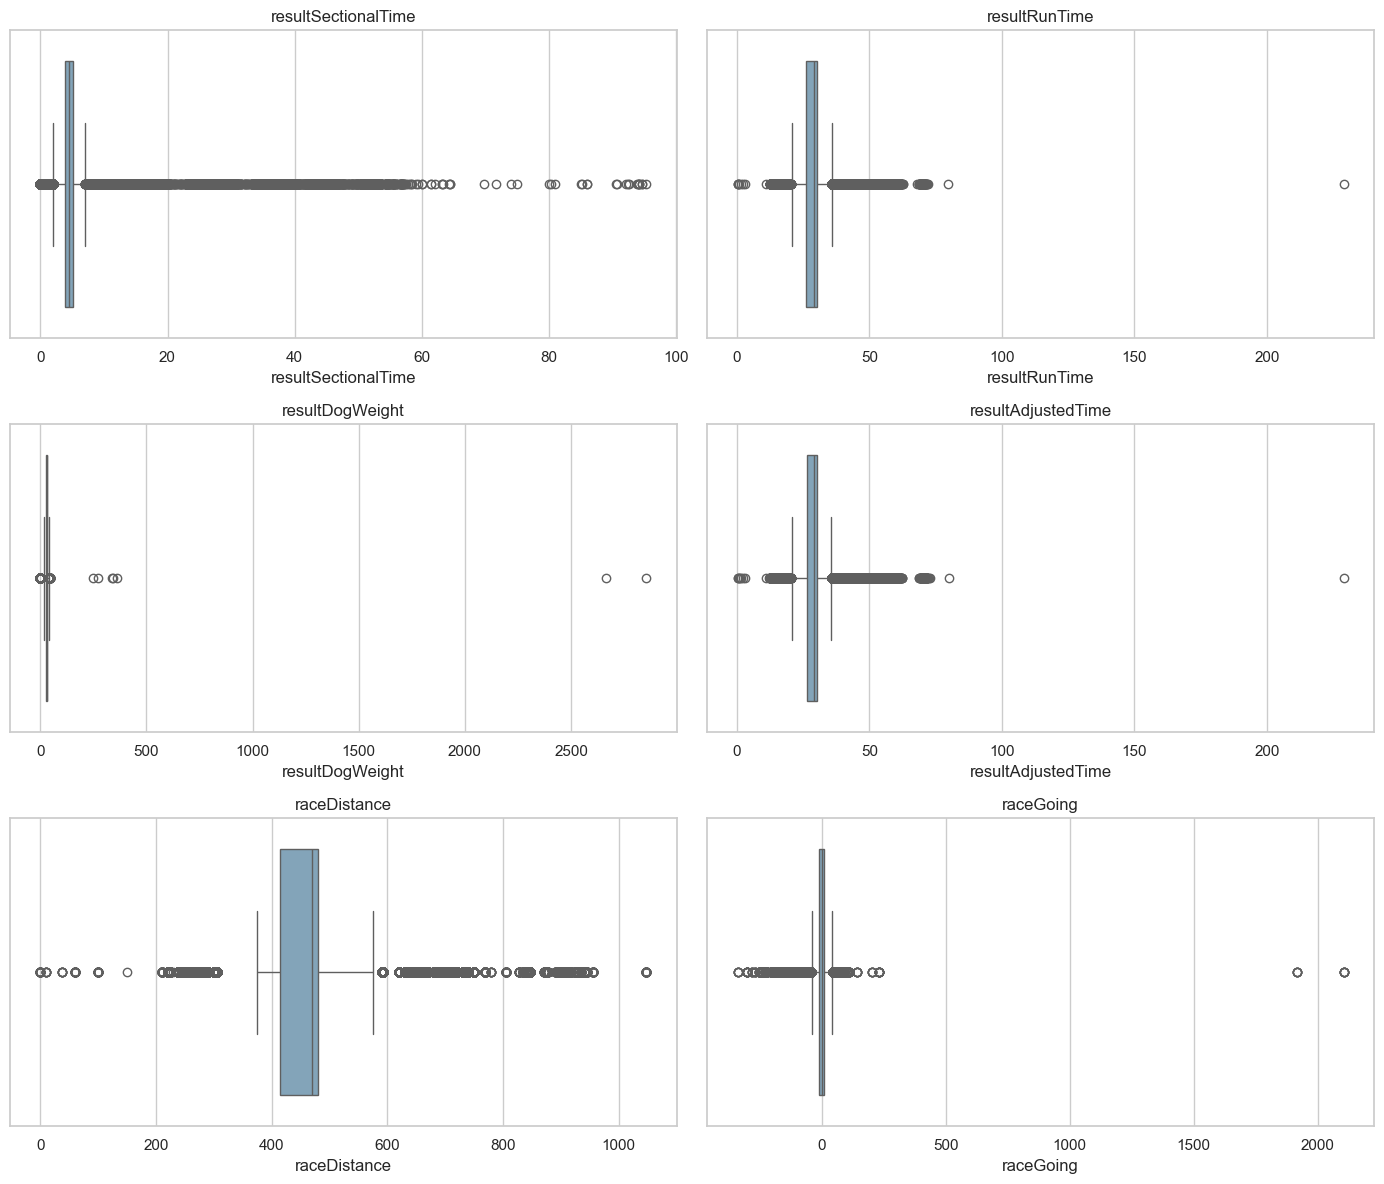

In [9]:

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
plot_cols = [
    "resultSectionalTime",
    "resultRunTime",
    "resultDogWeight",
    "resultAdjustedTime",
    "raceDistance",
    "raceGoing",
]

for ax, col in zip(axes.flatten(), plot_cols):
    sns.boxplot(x=pd.to_numeric(all_dog_infos[col], errors="coerce"), ax=ax, color="#7aa6c2")
    ax.set_title(col)

plt.tight_layout()
plt.show()



## Leakage and Modeling Semantics

Some columns are useful historical information only if they are lagged or aggregated from previous races.
They would be leakage if used directly to predict the same race outcome.


In [10]:

column_roles = pd.DataFrame([
    {"column": "dogId", "role": "identifier", "training_use": "drop from feature matrix, keep for joins/grouping"},
    {"column": "raceId", "role": "identifier", "training_use": "drop from feature matrix, keep for joins/grouping"},
    {"column": "meetingId", "role": "identifier", "training_use": "drop from feature matrix, keep for joins/grouping"},
    {"column": "trackName", "role": "feature", "training_use": "encode categorically"},
    {"column": "raceDate", "role": "feature", "training_use": "convert to datetime and derive calendar features"},
    {"column": "raceTime", "role": "feature", "training_use": "convert to time-based features"},
    {"column": "trapNumber", "role": "feature", "training_use": "coerce to integer, treat invalid traps as missing"},
    {"column": "SP", "role": "feature", "training_use": "parse to decimal odds and implied probability"},
    {"column": "raceDistance", "role": "feature", "training_use": "keep after impossible-value checks"},
    {"column": "raceGoing", "role": "feature", "training_use": "keep after impossible-value checks, impute missing"},
    {"column": "raceType", "role": "feature", "training_use": "encode categorically"},
    {"column": "raceClass", "role": "feature", "training_use": "encode categorically, fill missing with Unknown"},
    {"column": "resultPosition", "role": "target_or_leakage", "training_use": "do not use directly for same-race prediction"},
    {"column": "resultBtnDistance", "role": "post_race_outcome", "training_use": "only use as historical/lagged feature"},
    {"column": "resultSectionalTime", "role": "post_race_outcome", "training_use": "only use as historical/lagged feature"},
    {"column": "resultComment", "role": "post_race_outcome", "training_use": "only use as historical/lagged feature"},
    {"column": "resultRunTime", "role": "post_race_outcome", "training_use": "only use as historical/lagged feature"},
    {"column": "resultDogWeight", "role": "post_race_outcome", "training_use": "only use as historical/lagged feature"},
    {"column": "winnerOr2ndName", "role": "post_race_outcome", "training_use": "drop for same-race prediction"},
    {"column": "winnerOr2ndId", "role": "post_race_outcome", "training_use": "drop for same-race prediction"},
    {"column": "resultAdjustedTime", "role": "post_race_outcome", "training_use": "only use as historical/lagged feature"},
    {"column": "raceWinTime", "role": "post_race_outcome", "training_use": "only use as historical/lagged feature"},
]).sort_values(["role", "column"])

column_roles


,column,role,training_use
7,SP,feature,parse to decimal odds and implied probability
11,raceClass,feature,"encode categorically, fill missing with Unknown"
4,raceDate,feature,convert to datetime and derive calendar features
8,raceDistance,feature,keep after impossible-value checks
9,raceGoing,feature,"keep after impossible-value checks, impute mis..."
5,raceTime,feature,convert to time-based features
10,raceType,feature,encode categorically
3,trackName,feature,encode categorically
6,trapNumber,feature,"coerce to integer, treat invalid traps as missing"
0,dogId,identifier,"drop from feature matrix, keep for joins/grouping"
